# Mental Health in the Tech Industry: Análise Exploratória  
**Dataset:** [OSMI Mental Health in Tech Survey](https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey)

## **Business Understanding** (Entendimento do Negócio)

### Contexto
A saúde mental no ambiente de trabalho é um tema crítico, mas muitas vezes negligenciado, especialmente no setor de tecnologia, conhecido por altos níveis de estresse e cultura de alta performance. A **OSMI (Open Sourcing Mental Health)** realiza pesquisas anuais para medir as atitudes em relação à saúde mental e a frequência de transtornos de saúde mental no setor de tecnologia.

### Objetivos da Análise
O foco deste projeto é realizar uma análise descritiva completa para responder a perguntas como:
* Qual a prevalência de busca por tratamento de saúde mental entre profissionais de tecnologia?
* Existe uma correlação entre o tamanho da empresa e o suporte oferecido?
* Como o gênero e o trabalho remoto influenciam a percepção de saúde mental no trabalho?
* Quais são as maiores barreiras para um funcionário discutir saúde mental com seu supervisor?

## Setup

In [1]:
#Manipulação de dados 
import pandas as pd
import numpy as np

#Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns


#Estatística
from scipy.stats import chi2_contingency

#Modelagem
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

#Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    f1_score,
    recall_score
)

#Salvar/Carregar modelo
import joblib



In [2]:
#Definindo layout de gráficos 
sns.set_theme(
    style='whitegrid',
    rc={
        "figure.figsize": (10, 6),   
        "axes.titlesize": 18,           
        "axes.labelsize": 14,          
        "grid.alpha": 0.5
})

#Removendo warnings
import warnings
warnings.filterwarnings("ignore")




## **Data Understanding**

### Dicionário de Variáveis

Abaixo estão as descrições das colunas do dataset, conforme definido pela pesquisa original da OSMI:

#### **Dados Demográficos**
* **Timestamp:** Data e hora em que a resposta foi enviada.
* **Age:** Idade do respondente.
* **Gender:** Gênero do respondente (campo de texto livre).
* **Country:** País de residência.
* **state:** Se você mora nos Estados Unidos, em qual estado você reside.
* **self_employed:** Você trabalha por conta própria?

#### **Dados da Empresa**
* **family_history:** Você tem histórico familiar de doenças mentais?
* **treatment:** Você já procurou tratamento para uma condição de saúde mental?
* **no_employees:** Quantos funcionários sua empresa ou organização possui?
* **remote_work:** Você trabalha remotamente (fora do escritório) pelo menos 50% do tempo?
* **tech_company:** Seu empregador é primariamente uma empresa de tecnologia?

#### **Suporte e Benefícios na Empresa**
* **benefits:** Seu empregador oferece benefícios de saúde mental?
* **care_options:** Você conhece as opções de cuidado de saúde mental que seu empregador oferece?
* **wellness_program:** Seu empregador já discutiu saúde mental como parte de um programa de bem-estar corporativo?
* **seek_help:** Seu empregador fornece recursos para aprender mais sobre problemas de saúde mental e como procurar ajuda?
* **anonymity:** Seu anonimato é protegido caso você escolha utilizar recursos de saúde mental ou abuso de substâncias?
* **leave:** Quão fácil é para você tirar uma licença médica por uma condição de saúde mental?

#### **Percepções e Atitudes no Ambiente de Trabalho**
* **mental_health_consequence:** Você acha que discutir um problema de saúde mental com seu empregador teria consequências negativas?
* **phys_health_consequence:** Você acha que discutir um problema de saúde física com seu empregador teria consequências negativas?
* **coworkers:** Você estaria disposto a discutir um problema de saúde mental com seus colegas de trabalho?
* **supervisor:** Você estaria disposto a discutir um problema de saúde mental com seu supervisor direto?
* **mental_health_interview:** Você traria à tona um problema de saúde mental em uma entrevista com um potencial empregador?
* **phys_health_interview:** Você traria à tona um problema de saúde física em uma entrevista com um potencial empregador?
* **mental_vs_physical:** Você sente que seu empregador leva a saúde mental tão a sério quanto a saúde física?
* **obs_consequence:** Você já ouviu falar ou presenciou consequências negativas para colegas com condições de saúde mental no seu local de trabalho?
* **comments:** Quaisquer notas ou comentários adicionais.

In [3]:
#Carregando o dataset
df = pd.read_csv('../data/raw/survey.csv')

In [4]:
#Lendo primeiras linhas 
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [5]:
#Tipos de dados 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [6]:
#Verificando quanitdade de linhas e colunas 
df.shape

(1259, 27)

In [7]:
#Verificando dados nulos 
nulos = df.isnull().sum().sort_values(ascending=False)

#Porcentagem de dados nulos
porcentagem_nulos = nulos / len(df) * 100
porcentagem_nulos

comments                     86.973789
state                        40.905481
work_interfere               20.969023
self_employed                 1.429706
Gender                        0.000000
Timestamp                     0.000000
Age                           0.000000
family_history                0.000000
treatment                     0.000000
no_employees                  0.000000
Country                       0.000000
remote_work                   0.000000
tech_company                  0.000000
care_options                  0.000000
benefits                      0.000000
seek_help                     0.000000
anonymity                     0.000000
leave                         0.000000
wellness_program              0.000000
mental_health_consequence     0.000000
phys_health_consequence       0.000000
supervisor                    0.000000
coworkers                     0.000000
mental_health_interview       0.000000
phys_health_interview         0.000000
mental_vs_physical       

In [8]:
#Removendo a coluna comments 
df.drop('comments', axis=1, inplace=True)

> Decisão sobre ``comments`` : > A coluna foi removida devido à alta taxa de valores ausentes e por se tratar de texto não estruturado, o que foge do escopo desta análise descritiva quantitativa.

In [9]:
#Preenchendo nulos na coluna state 
df['state'].fillna('Not Applicable', inplace = True)

> **Decisão sobre `state` :** > A coluna state é dependente da coluna Country. Para evitar a perda de dados de outros países, os valores nulos foram categorizados como 'Não se aplica'."

In [10]:
#Preenchendo valores nulos na coluna 'work_interfere' com a moda
df['work_interfere'].fillna(df['work_interfere'].mode()[0], inplace = True)

> **Decisão sobre `work_interfere`:** > Identificamos que 21% dos respondentes não preencheram esta coluna. Em vez de excluir esses registros ou tentar adivinhar a resposta (imputação por moda), optamos por categorizá-los como **'Unknown'**. Isso preserva o tamanho da amostra e permite analisar se a falta de resposta está correlacionada com outras variáveis, como o estigma de falar sobre o assunto.

In [11]:
#Preenchendo nulos na coluna self_employed
df['self_employed'].fillna('No', inplace = True)

In [12]:
#Verificando nulos novamente
df.isnull().sum()

Timestamp                    0
Age                          0
Gender                       0
Country                      0
state                        0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

In [13]:
#Verificando dados duplicados 
df.duplicated().sum()

np.int64(0)

In [14]:
#Verificando a contagem de valores únicos na coluna no_employees
df['no_employees'].value_counts()

no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
500-1000           60
Name: count, dtype: int64

In [15]:
#Coluna no_employess
df['no_employees'].value_counts()

#Renomeando valores na coluna no_employees
df['no_employees'] = df['no_employees'].replace({'More than 1000' : '1000+'})

#Definindo a ordem lógica (Para o gráfico não bagunçar)
ordem_empresas = ['1-5', '6-25', '26-100', '100-500', '500-1000', '1000+']

#Aplicando a ordem lógica na coluna no_employees
df['no_employees'] = pd.Categorical(df['no_employees'], categories=ordem_empresas, ordered=True)

df['no_employees'].value_counts()

no_employees
6-25        290
26-100      289
1000+       282
100-500     176
1-5         162
500-1000     60
Name: count, dtype: int64

In [16]:
#Coluna Gender
df['Gender'].value_counts(ascending= False)

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female                                              2
Female (trans)                                      2
Male-ish                                            1
Trans-female                                        1
Male (CIS)                                          1
Mal                  

In [17]:
#Removendo espaços vazios e colocando em minusculo 
df['Gender'] = df['Gender'].str.strip().str.lower()

#Definir as listas de termos exatos
male_terms = ['male', 'm', 'man', 'cis male', 'malr', 'mail', 'make', 'cis man', 'msle', 'maile', 'cis-male']
female_terms = ['female', 'f', 'woman', 'femake', 'cis female', 'cis-female/femme', 'femail', 'cis-female', 'cis woman']

#Criar as condições
condicoes = [
    #Condição é feminino
    df['Gender'].isin(female_terms) | df['Gender'].str.contains('female'),
    
    #Condição é masculino
    df['Gender'].isin(male_terms) | df['Gender'].str.contains('male')
]

#Definir os resultados para cada condição
escolhas = ['Female', 'Male']

# 4. Aplicar (O default é o "else")
df['Gender'] = np.select(condicoes, escolhas, default='Non-Binary/Other')

# Verificando
print(df['Gender'].value_counts())


Gender
Male                993
Female              250
Non-Binary/Other     16
Name: count, dtype: int64


In [18]:
#Coluna leave 
df['leave'].value_counts()

#Renomeando valores na coluna leave
df['leave'] = df['leave'].replace({'Somewhat easy' : 'Easy', 'Very easy' : 'Easy',
                                   'Very difficult' : 'Difficult', 'Somewhat difficult' : 'Difficult',
                                   'Don\'t know' : 'Neutral'
                                   })

df['leave'].value_counts()

leave
Neutral      563
Easy         472
Difficult    224
Name: count, dtype: int64

####  Criando dados binários para análises futuras

In [19]:
#Criando um dicionário para mapear os valores a serem convertidos 
mapping = {'Yes' : 1,'No' : 0,
           'Easy' : 1, 'Neutral' : 0.5, 'Difficult' : 0,
           'Maybe' : 0.5, 'Don\'t know' : 0.5, 'Some of them' : 0.5, 'Not sure' : 0.5,
           'Often' : 1, 'Sometimes': 0.66, 'Rarely' : 0.5, 'Never' : 0
           }


In [20]:
#Identificamos as colunas que possuem esses termos (exceto demográficas como Country)
#Vamos focar nas colunas que realmente interessam para a correlação
cols_to_convert = [
    'treatment', 'family_history', 'benefits', 'care_options', 
    'wellness_program', 'seek_help', 'anonymity', 'leave', 
    'mental_health_consequence', 'phys_health_consequence', 
    'coworkers', 'supervisor', 'mental_health_interview', 
    'phys_health_interview', 'mental_vs_physical', 'obs_consequence',
    'remote_work', 'tech_company', 'work_interfere'
]

#Aplicando o replace de uma vez só
df_num = df.copy()
df_num[cols_to_convert] = df_num[cols_to_convert].replace(mapping)

In [21]:
#Convertendo as colunas convertidas a serem do tipo numérico
for col in cols_to_convert:
    df_num[col] = pd.to_numeric(df_num[col], errors='ignore')

### Criando variável 'Região'

In [22]:
#Criando a variável regiao
df['is_usa'] = df['Country'].apply(lambda x: 1 if x == 'United States' else 0)

In [23]:
#Convertendo a coluna Timestamp para datetime e extraindo o mês
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['month'] = df['Timestamp'].dt.month


In [24]:
#Coluna is_usa
df['is_usa'].value_counts()

#Padronizando para Sim/Não 
df['is_usa'] = df['is_usa'].replace({1 : 'Yes',
                      0 : 'No',
#Caso tenha sido carregado como texto
                      '1' : 'Yes',
                      '0' : 'No'
    
})

In [25]:
#Agrupando idades para análises futuras 
df['age_group'] = pd.cut(df['Age'], bins=[0, 18, 25, 35, 45, 60, 75],
                         labels=['<18', '18-25', '25-35', '35-45', '45-60', '60+'])

## **EDA**

## Análise Univariada

#### **Variáveis numéricas**

In [26]:
#Infos gerais 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Timestamp                  1259 non-null   datetime64[ns]
 1   Age                        1259 non-null   int64         
 2   Gender                     1259 non-null   object        
 3   Country                    1259 non-null   object        
 4   state                      1259 non-null   object        
 5   self_employed              1259 non-null   object        
 6   family_history             1259 non-null   object        
 7   treatment                  1259 non-null   object        
 8   work_interfere             1259 non-null   object        
 9   no_employees               1259 non-null   category      
 10  remote_work                1259 non-null   object        
 11  tech_company               1259 non-null   object        
 12  benefi

In [27]:
#Criando variável das colunas numéricas
num_cols = df.select_dtypes(include = ['int64', 'int32', 'float64'])


99999999999
-1726


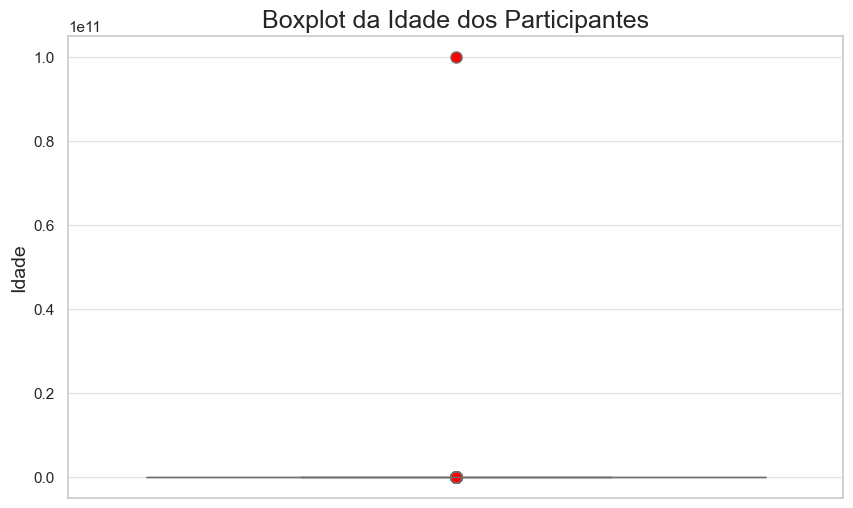

In [28]:
#Valor min e maximo da coluna age
print(num_cols['Age'].max()) 
print(num_cols['Age'].min())


#Boxplot da coluna Age 
sns.boxplot(num_cols['Age'], color='skyblue', flierprops = dict(
    marker='o',
    markerfacecolor='red',
    markersize=8
    
) )

#Títulos e eixos 
plt.title('Boxplot da Idade dos Participantes')
plt.ylabel('Idade')
plt.show()

#### **Análise** : 

Análise de Integridade da Variável Age
1. Diagnóstico: Inconsistência severa nos dados. Os dados revelam a presença de ruídos críticos que inviabilizam qualquer análise estatística direta antes do tratamento:

Valor Mínimo (-1726): Impossível biologicamente. Indica provável erro de digitação 

Valor Máximo (99.999.999.999): Aproximadamente 100 bilhões de anos. Isso é claramente um dado inserido propositalmente de forma errada ("trolling") por um participante da pesquisa, já que é um campo de texto aberto.

2. Impacto na Visualização (O "Boxplot Vazio") O comportamento visual observado (gráfico achatado ou "vazio") é uma consequência direta desses extremos:

Colapso de Escala: O matplotlib/seaborn tentou criar um Eixo Y que abrangesse de -1.700 até 100 Bilhões.

Compressão dos Dados Reais: A faixa de dados válida (pessoas entre 18 e 60 anos) representa uma fração infinitesimal desse eixo. Visualmente, toda a população real foi espremida em uma linha menor que um pixel na base do gráfico.

3. Impacto nas Estatísticas Descritivas

Média (Mean): Está completamente corrompida. Esse único valor de 100 bilhões puxará a média de idade para um número absurdo (provavelmente milhões de anos), tornando-a inútil para descrever o perfil do profissional de tecnologia.

Desvio Padrão: Será gigantesco, indicando uma dispersão falsa.

Conclusão e Próximo Passo
Esses dados não são outliers naturais (pontos fora da curva estatística normal), são erros de dados. O tratamento aqui não deve ser estatístico (como IQR), mas sim lógico (Regra de Negócio).

Ação: Aplicar um "Hard Filter" (Filtro Rígido) baseado na realidade do mercado de trabalho e biologia humana.


In [29]:
#Definindo que trabalhadores da área de tech têm entre 18 e 100 anos
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

#Verificando se a limpeza funcionou
print(f"Linhas depois: {df.shape[0]}")
print(f"Idade Mínima: {df['Age'].min()}")
print(f"Idade Máxima: {df['Age'].max()}")

Linhas depois: 1251
Idade Mínima: 18
Idade Máxima: 72


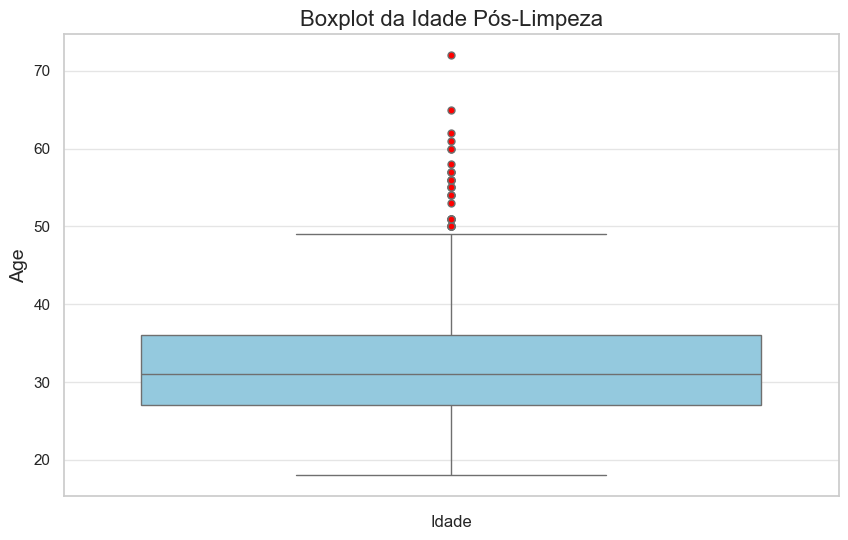

In [30]:
#Boxplot da Idade (Limpa)
plt.figure(figsize=(10, 6))
sns.boxplot(df['Age'], color='skyblue', flierprops=dict(
    marker='o', markerfacecolor='red', markersize=5))

plt.title('Boxplot da Idade Pós-Limpeza', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.show()

### 1. Medidas de Tendência Central e Posição

* **Conclusão:** A maior concentração de dados (o "meio" da distribuição, ou 50% dos casos) é relativamente jovem, situando-se num intervalo estreito de cerca de 9 anos (entre 27 e 36 anos).

### 2. Dispersão e Limites (Whiskers)

* **Limite Inferior:** O "whisker" inferior estende-se até **18 anos**. Isso confirma que o filtro (`idade >= 18`) funcionou corretamente e há dados presentes nesse limite mínimo.
* **Limite Superior:** O "whisker" superior vai até cerca de **50 anos**. Estatisticamente, qualquer valor acima disso é considerado um *outlier* neste conjunto específico (calculado geralmente como ).

### 3. Análise de Outliers

* **Pontos Vermelhos:** Observamos uma série de *outliers* (valores discrepantes) acima de 50 anos, indo até aproximadamente **72 anos**.
* **Interpretação:** Embora sejam *outliers* estatísticos (fogem do padrão de concentração jovem da amostra), eles **não parecem ser erros de dados** (ruído), pois idades entre 50 e 72 são perfeitamente plausíveis para uma população adulta.
* **Nota sobre o Filtro:** Você mencionou filtrar até 100 anos, mas o valor máximo observado foi ~72. Isso indica que, ou não havia pessoas acima dessa idade na base original, ou a amostragem nessa faixa etária é inexistente.


In [31]:
#Verificando a % de dados considerados outliers em Age 

#Primeiro calculamos o IQR
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

#Limites inferiores e superiores 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Filtrar e contar os outliers 
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

#Filtrando os resultados
qtd_outliers = len(outliers)
total_registros = len(df)
porcentagem = (qtd_outliers / total_registros) * 100

#Exibir os resultados
print(f"Limite Superior calculado (corte): {upper_bound:.2f} anos")
print(f"Total de registros analisados: {total_registros}")
print(f"Quantidade de Outliers encontrados: {qtd_outliers}")
print(f"Representatividade: {porcentagem:.2f}% da base")


Limite Superior calculado (corte): 49.50 anos
Total de registros analisados: 1251
Quantidade de Outliers encontrados: 32
Representatividade: 2.56% da base


#### Analisando os possíveis 32 "Outliers" (2.56%)

* **São Dados Legítimos, não Ruído:** Diferente de uma idade impossível (ex: 200 anos), profissionais entre **50 e 72 anos** são uma realidade no mercado. Tratá-los como erro seria falsificar a realidade da amostra.
* **Evita o Viés de Seleção:** Remover esses registros cria um modelo "cego" para profissionais seniores. Se você excluir essa faixa etária, seu modelo aprenderá que o mundo acaba aos 49.5 anos, falhando ao prever ou classificar qualquer pessoa acima disso no futuro (produção).
* **Baixo Impacto Negativo:** Como representam apenas **2.56%** da base, eles não têm volume suficiente para distorcer drasticamente a média geral, mas garantem a variabilidade necessária para um modelo robusto.
* **Melhora a Generalização:** Para algoritmos de Machine Learning (especialmente árvores de decisão como Random Forest ou XGBoost), ter esses exemplos extremos ajuda o modelo a entender melhor as fronteiras de decisão do mundo real.

**Conclusão:** Vamos mantê-los a fim de enriquecer o aprendizado do modelo sem introduzir sujeira nos dados.

In [32]:
#Verificando mais medidas centrais e de dispersão da coluna age
df['Age'].describe()

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64

Text(0, 0.5, 'Contagem')

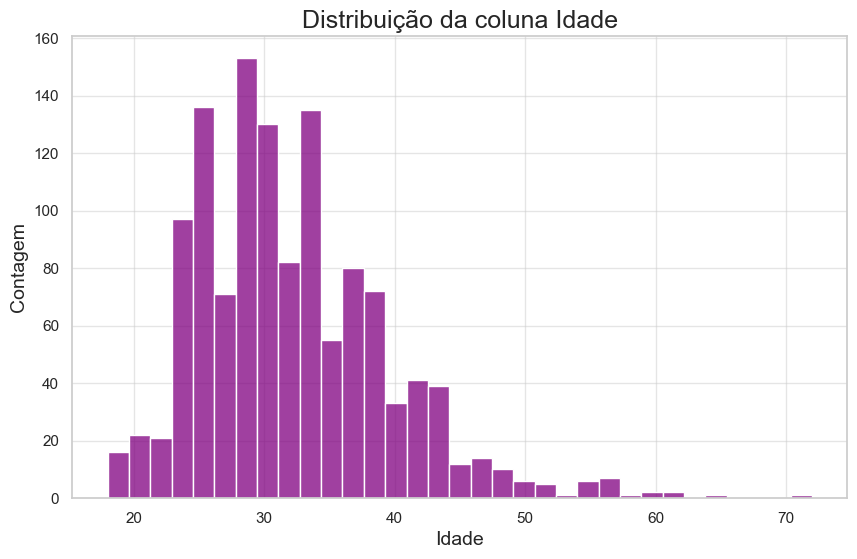

In [33]:
#Distribuição dos dados de age 
sns.histplot(df['Age'], color = 'Purple')

#Títulos e eixos
plt.title('Distribuição da coluna Idade')
plt.xlabel('Idade')
plt.ylabel('Contagem')

#### Resumo sobre histograma (distribuição) da coluna 'Age'

* **Público Jovem:** O perfil dominante é de profissionais em início/meio de carreira (25-35 anos).
* **Seniores são Raros:** A frequência cai drasticamente após os 45 anos, indicando que profissionais seniores são escassos nesta amostra específica.


### Relatório de Análise: Variável `Age` (Idade)

#### 1. Perfil Demográfico Predominante

A base de dados apresenta uma população majoritariamente **Jovem Adulta**.

* **Core do Dados (50%):** Metade de todos os indivíduos está concentrada em uma faixa estreita de 9 anos, situada entre **27 e 36 anos** (Intervalo Interquartil - IQR).
* **Ponto Central:** A mediana de **31 anos** indica que a "força" da amostra está no início/meio de carreira ou fase adulta inicial.
* **Pico de Frequência:** A idade mais comum (moda) gira em torno de **29-30 anos**.

#### 2. Comportamento da Distribuição

* **Assimetria Positiva (À Direita):** A distribuição não é normal (gaussiana). Ela possui uma cauda longa que se estende em direção às idades mais avançadas.
* **Volatilidade:** A variação de idade é baixa no início (subida rápida até os 30) e alta no final (dispersão lenta após os 45).

#### 3. Integridade e Outliers

* **Qualidade dos Dados:** O filtro (18-100 anos) garantiu que não há ruídos impossíveis (ex: idades negativas ou irreais).
* **Análise de Discrepantes:** Identificamos **32 registros (2.56%)** acima do limite estatístico de **49.5 anos**.
* *Veredito:* São **outliers naturais**, representando profissionais seniores.
* *Ação:* **Mantidos na base**, pois removê-los introduziria viés contra a faixa etária sênior.


#### 4. Insights Estratégicos (Negócio)

* **Escassez de Seniores:** Há uma queda abrupta na frequência de indivíduos após os 45 anos. Se este dataset for de funcionários ou candidatos, isso indica uma dificuldade de retenção ou atração de profissionais mais experientes.
* **Foco de Comunicação:** Qualquer ação baseada nestes dados (marketing, benefícios, linguagem) deve ser priorizada para a persona de **25 a 35 anos**, onde reside a massa crítica da amostra.



### Idade vs Tratamento

Text(0, 0.5, 'Idade')

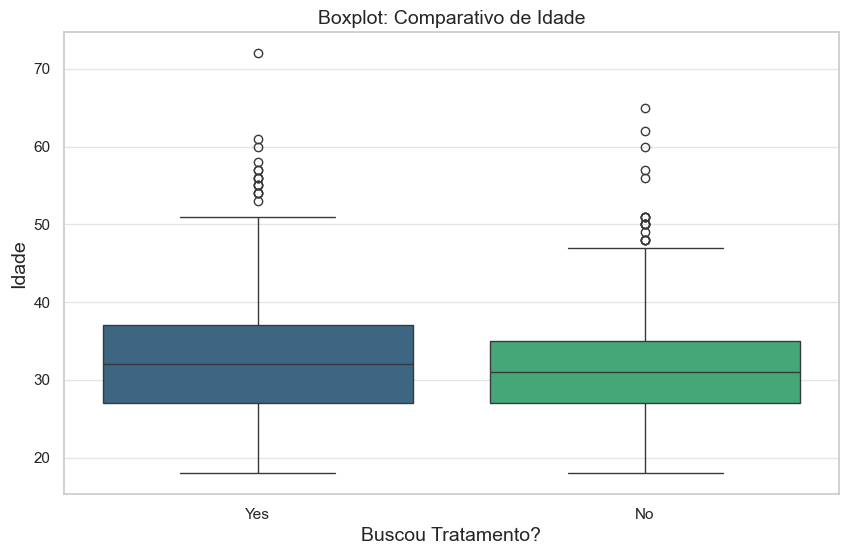

In [34]:

#Boxplot (Comparação de Medianas e Dispersão)
sns.boxplot(data=df, x='treatment', y='Age', palette="viridis", order=['Yes', 'No'])
plt.title('Boxplot: Comparativo de Idade', fontsize=14)
plt.xlabel('Buscou Tratamento?')
plt.ylabel('Idade')




O boxplot  compara a **distribuição etária** de profissionais da área de tecnologia que **procuraram tratamento para a saúde mental** (“Yes”) com aqueles que **não procuraram** (“No”).

**Interpretação geral:**

O gráfico sugere que, na área de tecnologia, a procura por tratamento em saúde mental **não é exclusiva de um grupo etário específico**, mas tende a ser **ligeiramente mais comum entre profissionais mais velhos ou com maior experiência**. Isto pode estar relacionado com maior maturidade emocional, maior estabilidade financeira para procurar apoio, ou maior exposição acumulada a fatores de stress ao longo da carreira.



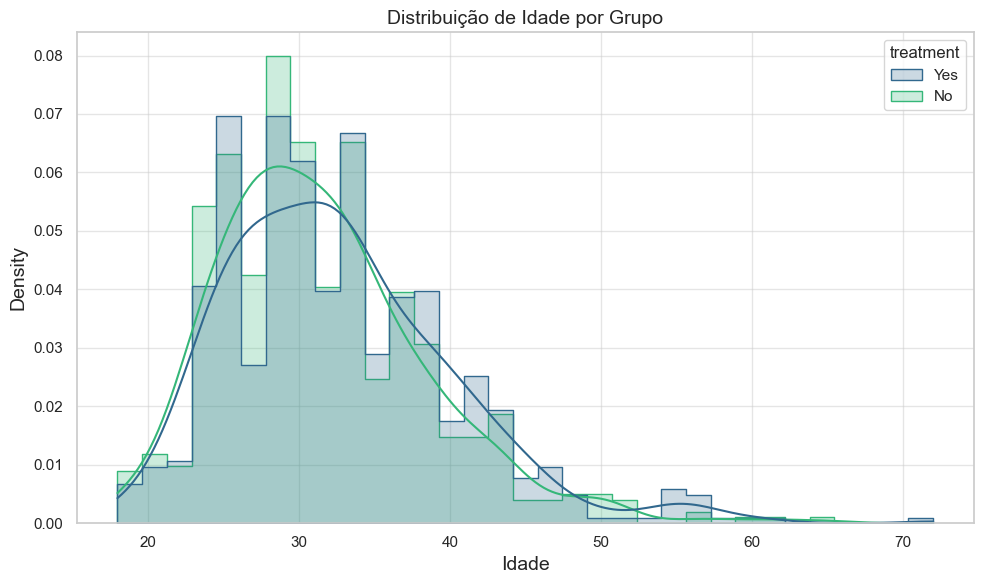

In [35]:
#Histograma Sobreposto (Comparação de Formato)
sns.histplot(data=df, x='Age', hue='treatment', kde=True, 
             element="step", stat="density", common_norm=False, 
             palette="viridis", hue_order=['Yes', 'No'])
plt.title('Distribuição de Idade por Grupo', fontsize=14)
plt.xlabel('Idade')

plt.tight_layout()
plt.show()

**Conclusão da Análise Combinada (Boxplot + Histograma)**
Ao juntar as duas análises, a história dos dados fica clara:

O Comportamento Padrão: A idade não é um divisor de águas. Jovens de 30 anos são a maioria tanto no grupo que busca quanto no que não busca tratamento.

A Nuance: Existe uma tendência sutil, mas visível: conforme a idade avança (especialmente após os 40 anos), a probabilidade de a pessoa pertencer ao grupo "Yes" (Buscou Tratamento) parece aumentar ligeiramente em comparação ao grupo "No".

Nota visual: As barras azuis ultrapassam as verdes consistentemente na faixa dos 50-60 anos.

#### **Variáveis categóricas**

In [36]:
#Verficando colunas categóricas
cat_cols = df.select_dtypes(include = ['object', 'category'])

cat_cols.columns

Index(['Gender', 'Country', 'state', 'self_employed', 'family_history',
       'treatment', 'work_interfere', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'is_usa', 'age_group'],
      dtype='object')

### Qual a prevalência de busca por tratamento de saúde mental entre profissionais de tecnologia?

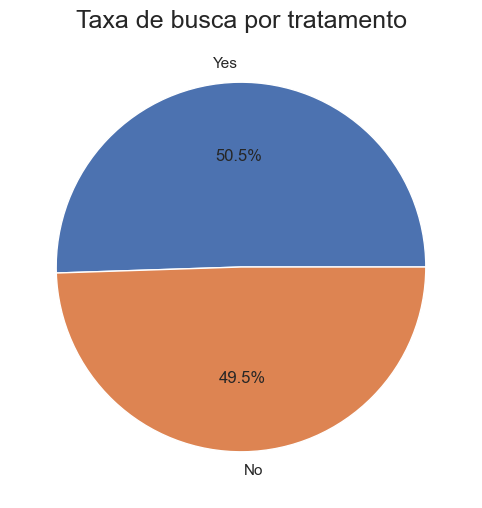

In [37]:
#Calcular percentuais
tr_counts = df['treatment'].value_counts(normalize=True) * 100

#Visualização
plt.pie(tr_counts, labels=tr_counts.index, autopct='%1.1f%%')
plt.title('Taxa de busca por tratamento')
plt.show()


* **50.5%** buscam tratamento
* **49.5%** não buscam tratamento
* **Conclusão:** A variável alvo (target) não sofre de **desbalanceamento de classes**.


### Existe uma correlação entre o tamanho da empresa e o suporte oferecido?

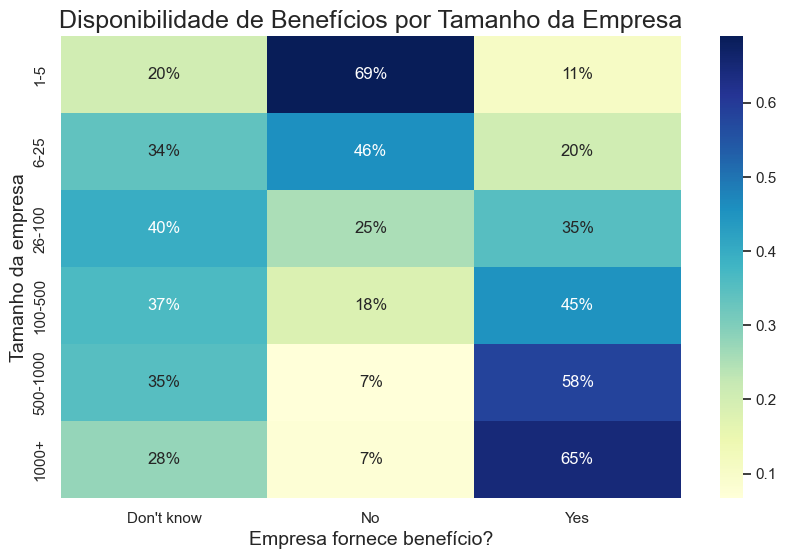

In [38]:
#Visualização com heatmap
ct = pd.crosstab(df['no_employees'], df['benefits'], normalize='index')
ct = ct.reindex(ordem_empresas) 

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title('Disponibilidade de Benefícios por Tamanho da Empresa')
plt.xlabel('Empresa fornece benefício?')
plt.ylabel('Tamanho da empresa')
plt.show()

#### Insight:

Conclusão Estratégica

* Se você trabalha em uma startup ou microempresa, a expectativa padrão é não ter cobertura.

* Se você está em uma empresa média, há uma grande chance de o benefício existir, mas você não saber (o que indica uma oportunidade de melhoria na comunicação interna dessas empresas).

* Se você está em uma grande empresa, o benefício é quase garantido.

### Qual a influencia do gêrenero e do trabalho remoto em busca de tratamento?

<Figure size 1000x600 with 0 Axes>

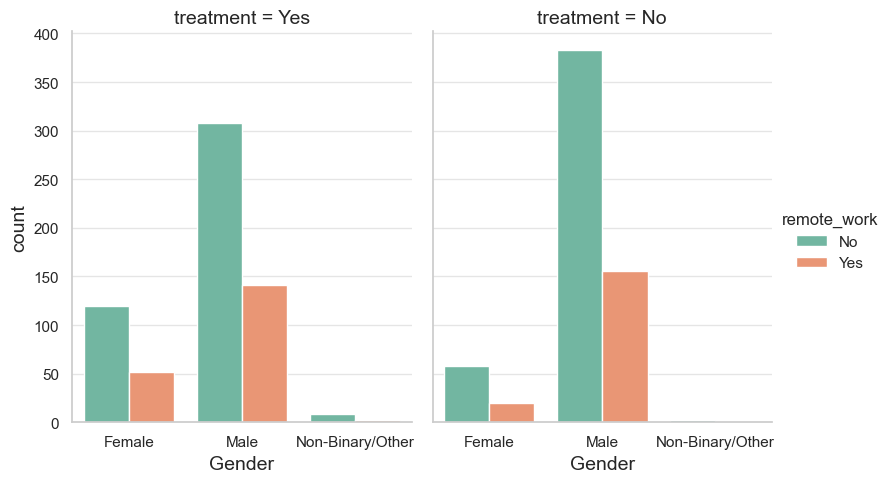

In [39]:
#Qual genêro busca mais tratamento em trabalho remoto
plt.figure(figsize=(10, 6))
sns.catplot(x="Gender", hue="remote_work", col="treatment",
            data=df, kind="count", height=5, aspect=.8, palette="Set2")
plt.show()

#### **Insights:**

O gráfico conta uma história clara sobre **comportamento de gênero**:
Enquanto a maioria dos funcionários são homens que trabalham presencialmente e tendem a **não** buscar tratamento, as mulheres (embora em menor número na empresa) são proporcionalmente muito mais propensas a cuidar da saúde mental.


### Quais são as maiores barreiras para um funcionário discutir saúde mental com seu supervisor?

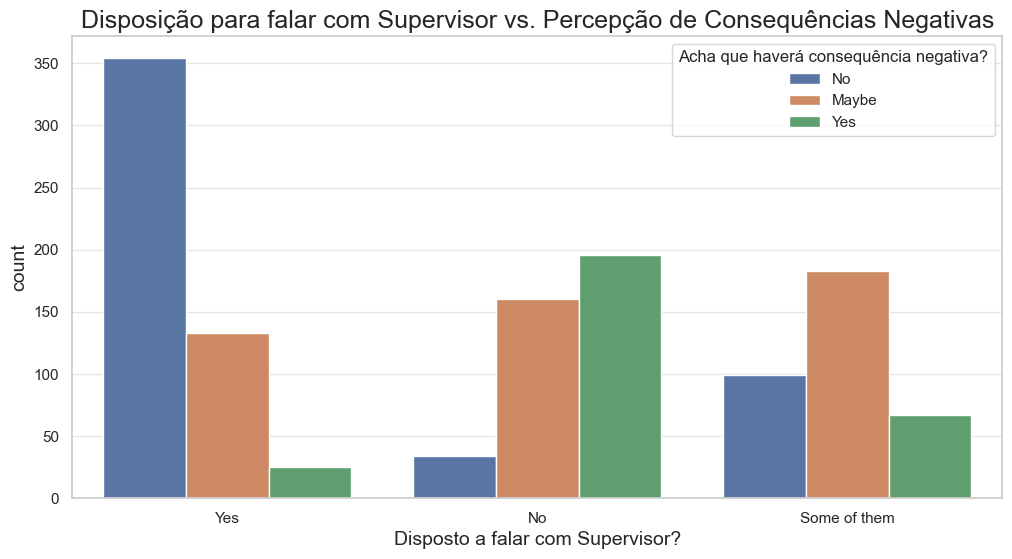

In [40]:
#Gráfico de barras 
plt.figure(figsize=(12, 6))
sns.countplot(x='supervisor', hue='mental_health_consequence', data=df, order=['Yes', 'No', 'Some of them'])
plt.title('Disposição para falar com Supervisor vs. Percepção de Consequências Negativas')
plt.xlabel('Disposto a falar com Supervisor?')
plt.legend(title='Acha que haverá consequência negativa?')
plt.show()

#### **Insights**

Este gráfico prova visualmente a teoria da Segurança Psicológica:

* Correlação Inversa: Existe uma correlação inversa quase perfeita entre a disposição para falar e o medo de retaliação.

* O Problema é a cultura, não o indivíduo: Se os funcionários não estão reportando problemas de saúde mental, o gráfico sugere que o problema não é a timidez deles, mas a percepção de que a empresa (ou o supervisor) irá puni-los.

In [41]:
#Denindo mais colunas a serem análisadas 
cols_to_analyze = ['treatment', 'family_history', 'work_interfere', 'benefits']

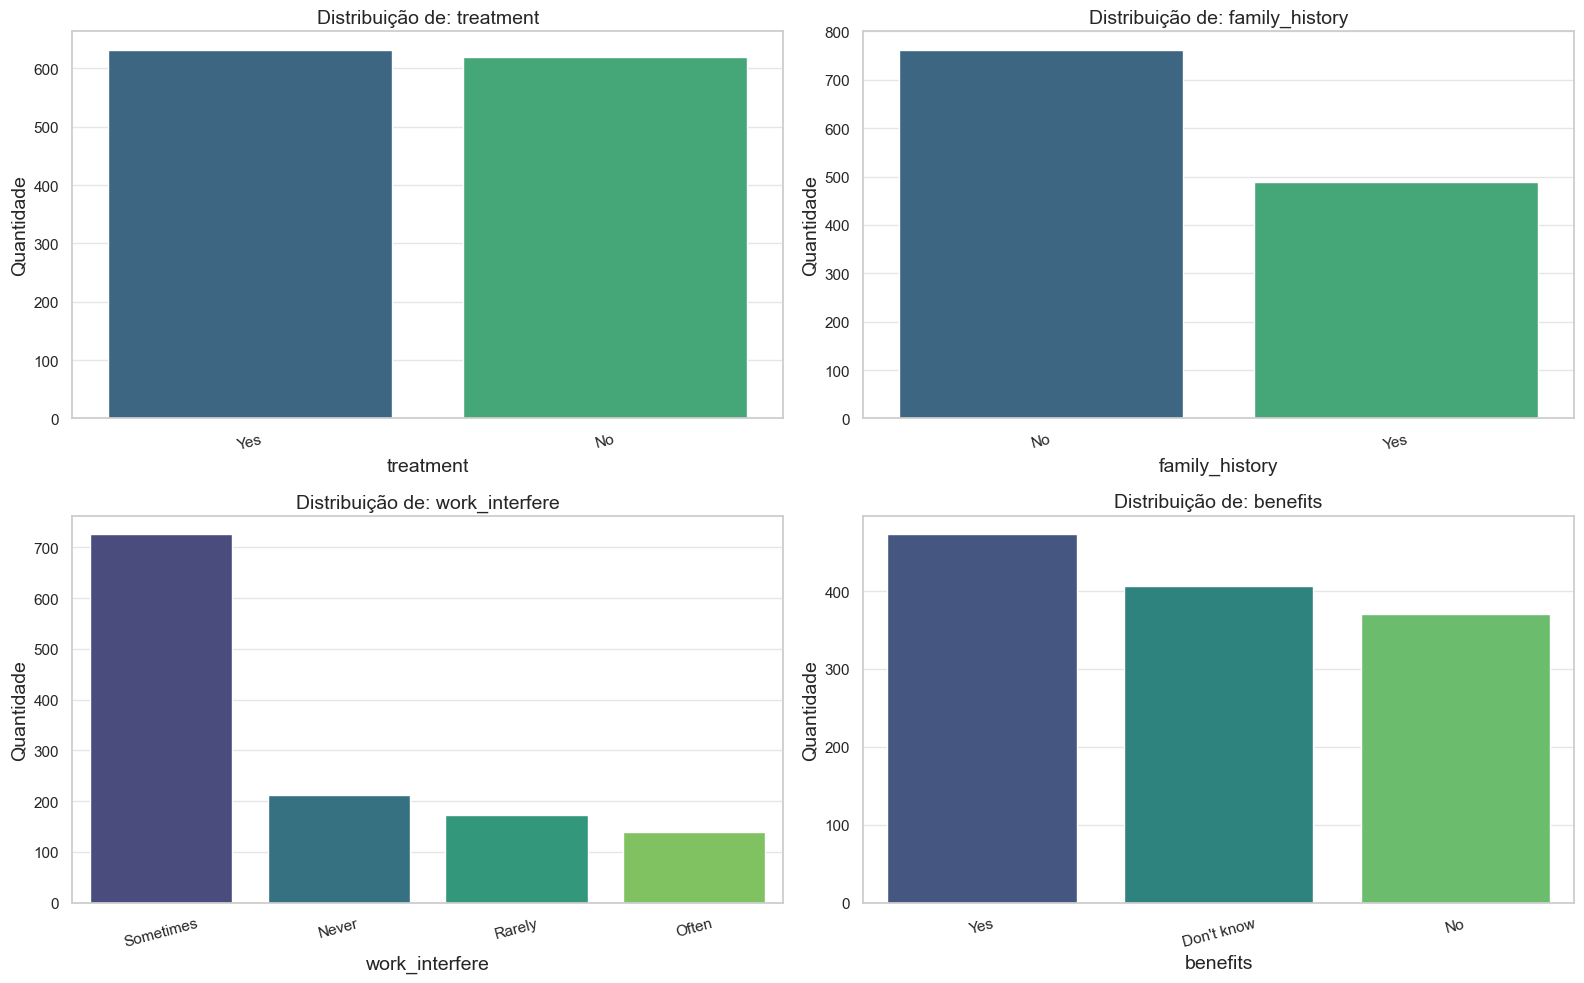

In [42]:
#Multiplos gráficos de barras
fig, axes = plt.subplots(2,2, figsize = (16,10))
axes = axes.flatten()

for i, col in enumerate(cols_to_analyze):
    sns.countplot(data= df, x = col, 
                ax= axes[i], 
                palette= 'viridis',
                order = df[col].value_counts().index #ordena do maior p o menor
                
                )

    axes[i].set_title(f'Distribuição de: {col}', fontsize=14)
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=15) 

plt.tight_layout()
plt.show()


#### **Insights**

Análise detalhada de cada quadrante:

#### 1. Superior Esquerdo: `treatment` (Buscou Tratamento?)

* **O Equilíbrio Perfeito:** As barras "Yes" (Sim) e "No" (Não) têm alturas quase idênticas (ambas em torno de 600-630 pessoas).
* **Insight:** A base de dados está incrivelmente balanceada. Metade da amostra buscou ajuda profissional e a outra metade não.

#### 2. Superior Direito: `family_history` (Histórico Familiar)

* **Predominância do "Não":** A maioria das pessoas (barra azul) relata **não** ter histórico de doenças mentais na família (aprox. 750 vs 490).
* **Relevância do "Sim":** Apesar de menor, o grupo com histórico familiar é bastante grande (quase 40% da amostra). Dado que o histórico familiar é um forte preditor biológico para condições mentais, este é um grupo de risco significativo.

#### 3. Inferior Esquerdo: `work_interfere` (Interferência no Trabalho)

* **O Gigante "Sometimes" (Às vezes):** Esta é a distribuição mais reveladora. A categoria "Sometimes" (roxo escuro) é, de longe, a resposta mais comum, superando 700 respostas.
* **Sinal de Alerta:** A soma de "Sometimes" + "Often" (Frequentemente) + "Rarely" (Raramente) mostra que a **esmagadora maioria** sente que sua saúde mental impacta seu trabalho em algum nível.
* **A Minoria "Never":** Apenas um grupo pequeno (aprox. 200 pessoas) diz que "Nunca" sente interferência. Isso sugere que, para este público, saúde mental e desempenho profissional estão intrinsecamente ligados.

#### 4. Inferior Direito: `benefits` (Benefícios de Saúde)

* **A Incerteza Reina:** Embora "Yes" (Sim) seja a resposta mais frequente, a barra "Don't know" (Não sei) é muito alta (segunda maior), quase empatada com o "Sim".
* **Conexão com Análise Anterior:** Isso confirma o que vimos no mapa de calor anterior: existe uma falha massiva de comunicação. Quase tantas pessoas *não sabem* se têm benefícios quanto as que *sabem* que têm.
* **O "Não":** É a menor barra, o que é positivo, indicando que a ausência total de benefícios é o cenário menos comum (embora ainda representativo).

#### Síntese Geral do Perfil

Se cruzarmos essas quatro informações, podemos desenhar o perfil típico deste conjunto de dados:

> "É um grupo dividido meio a meio sobre buscar tratamento, onde a maioria sente que a saúde mental interfere 'às vezes' no trabalho, mas muitos não sabem se a empresa oferece suporte para isso, apesar de a maioria não ter um histórico familiar pesado da condição."


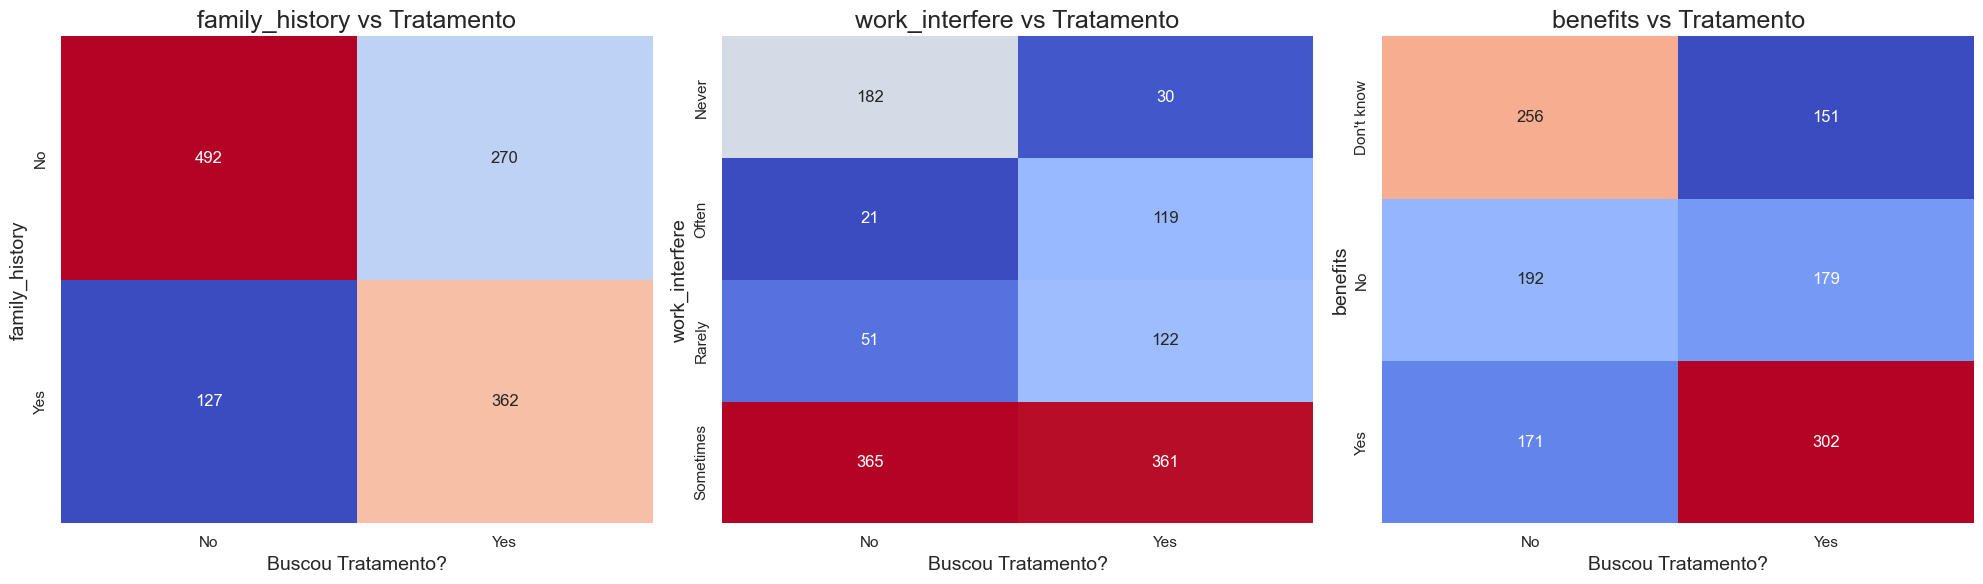

In [43]:
#Definindo as variáveis preditoras
preditoras = ['family_history', 'work_interfere', 'benefits']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(preditoras):
    #Matriz de Frequência)
    matriz = pd.crosstab(df[col], df['treatment'])
    
    #Heatmap
    sns.heatmap(
        matriz, 
        annot=True,     
        fmt='d',        
        cmap='coolwarm',  
        ax=axes[i],
        cbar=False     
    )
    axes[i].set_title(f'{col} vs Tratamento')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Buscou Tratamento?')

plt.tight_layout()
plt.show()


#### Síntese dos 3 Gráficos

Podemos traçar o "Caminho da Busca por Ajuda":

1. **Gatilho Biológico:** Se você tem histórico familiar, você já está propenso a buscar.
2. **Gatilho de Dor:** Se interfere no seu trabalho frequentemente, você vai buscar ajuda.
3. **Facilitador:** Se você sabe que a empresa paga (benefícios), você se sente encorajado a ir.

**Onde a empresa falha?**
Nos grupos intermediários: pessoas que sentem interferência "às vezes" e pessoas que "não sabem" se têm benefícios.



## **Relatório de Análise: Saúde Mental na Tecnologia**

### 1. Perfil Demográfico e Risco

A força de trabalho analisada apresenta características muito específicas que influenciam diretamente os resultados:

* **Faixa Etária (Jovens Adultos):** A grande massa de trabalhadores está entre **25 e 35 anos**. A idade **não é um fator determinante** para buscar tratamento, embora exista uma leve tendência de pessoas mais velhas (40+) buscarem mais ajuda do que os muito jovens (que tendem a negligenciar).
* **Gênero (Disparidade de Comportamento):** O setor é majoritariamente masculino, mas os **homens buscam proporcionalmente menos tratamento** do que as mulheres. As mulheres demonstram maior conscientização e proatividade em relação à saúde mental.
* **Fator Genético:** Ter histórico familiar de doença mental é um dos preditores mais fortes para a busca de tratamento. Quem tem histórico, busca ajuda; quem não tem, tende a evitar.

### 2. O Ambiente Corporativo e Benefícios

A estrutura da empresa dita a disponibilidade de recursos, mas a comunicação é a falha crítica.

* **Tamanho da Empresa:** Existe uma correlação linear: quanto maior a empresa, maior a chance de haver benefícios de saúde mental.
* *Microempresas (1-5):* Geralmente não têm recursos.
* *Grandes (>1000):* Têm recursos e processos claros.


* **O "Limbo" das Médias Empresas:** Em empresas de médio porte (26-500 funcionários), há uma **crise de comunicação**. Uma parcela enorme de funcionários respondeu **"Não sei"** sobre a existência de benefícios.
* **Impacto da Ignorância:** Os dados provam que **não saber** se tem benefício tem o mesmo efeito prático de **não ter**. O grupo "Don't know" tem baixíssima taxa de busca por tratamento.

### 3. Cultura, Segurança Psicológica e Trabalho

A cultura organizacional atua como barreira ou facilitador.

* **Medo de Consequências:** Há uma relação inversa perfeita. Quem tem medo de sofrer retaliação ou julgamento negativo **não fala** com o supervisor. A transparência só existe onde há segurança psicológica.
* **Interferência no Trabalho:** A dor move a ação. Pessoas que sentem que a saúde mental interfere "Frequentemente" no trabalho buscam ajuda massivamente.
* *O Grupo de Risco Oculto:* O maior grupo é o que sente interferência **"Às vezes"**. Esse grupo está dividido meio a meio entre buscar ou não ajuda. Eles sofrem, mas talvez não o suficiente para vencer o estigma sozinhos.



### 4. Conclusão Executiva (O "Diagnóstico")

O setor de tecnologia enfrenta um cenário onde **a infraestrutura (benefícios) muitas vezes existe, mas não chega ao funcionário devido a falhas de comunicação e estigma.**

O perfil típico de quem **NÃO** busca ajuda, mesmo precisando, é:

> *Homem, jovem (20-30 anos), trabalha em empresa de médio porte, não sabe se tem direito a psicólogo pelo plano, tem medo de ser julgado pelo chefe e acha que seus problemas só atrapalham o trabalho "de vez em quando".*

### 5. Recomendações Estratégicas Baseadas em Dados

1. **Eliminar o "Não Sei":** Campanhas agressivas de comunicação interna sobre benefícios. Converter o grupo "Don't Know" em "Yes" aumentaria drasticamente a busca por tratamento.
2. **Foco no Público Masculino:** As campanhas atuais parecem funcionar melhor para mulheres. É necessário uma linguagem diferente para engajar os homens, que são a maioria da força de trabalho e os mais resistentes.
3. **Treinamento de Liderança (Segurança Psicológica):** Os dados mostram que ninguém fala com o supervisor se houver percepção de consequência negativa. Treinar gestores para acolhimento é a única forma de quebrar o silêncio.
4. **Atenção ao Sintoma "Às Vezes":** Não espere o funcionário colapsar ("Frequentemente"). Programas preventivos devem focar em quem sente impactos esporádicos ("Sometimes"), evitando que o quadro se agrave.


## **Feature Selection**

* Após fazer todas as análises descritivas do nosso conjunto de dados e gerar insights, vamos analisar a features (atributos) que mais tem importancia ao profissional procurar tratamento.

In [44]:
#Definindo nossa target 
target = 'treatment'

#Definindo as colunas categoricas
cat_cols = df.select_dtypes(include= ['object', 'category']).columns.tolist()

#Retirando a target 
if target in cat_cols:
    cat_cols.remove(target)
    

print(cat_cols)

['Gender', 'Country', 'state', 'self_employed', 'family_history', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'is_usa', 'age_group']


In [45]:
#Lista para colocar os resultados 
results = []

#Calculo qui-quadrado
for col in cat_cols:
    
    #Confusion matrix
    confusion_matrix = pd.crosstab(df[col], df[target])
    
    #Calculos estatísticos (chi square)
    chi2_val = chi2_contingency(confusion_matrix)[0] #calcula o valor de chi (qui-quadrado)
    n = confusion_matrix.sum().sum() #número total de linhas 
    phi2 = chi2_val / n  #coeficiente de phi ao quadrado (medida de preliminar de correlação)
    r, k = confusion_matrix.shape #número de linhas e colunas da matrix
    
    #Correção de viés para V de Crammer (evita erros de divisão por 0)
    if min(k-1, r-1) == 0:
        cramer_val = 0.0
    else:
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        
        # Denominador da fórmula
        denominator = min((kcorr-1), (rcorr-1))
        
        if denominator == 0:
            cramer_val = 0.0
        else:
            cramer_val = np.sqrt(phi2corr / denominator)
    
    results.append({'Variável': col, 'Score': cramer_val})
    

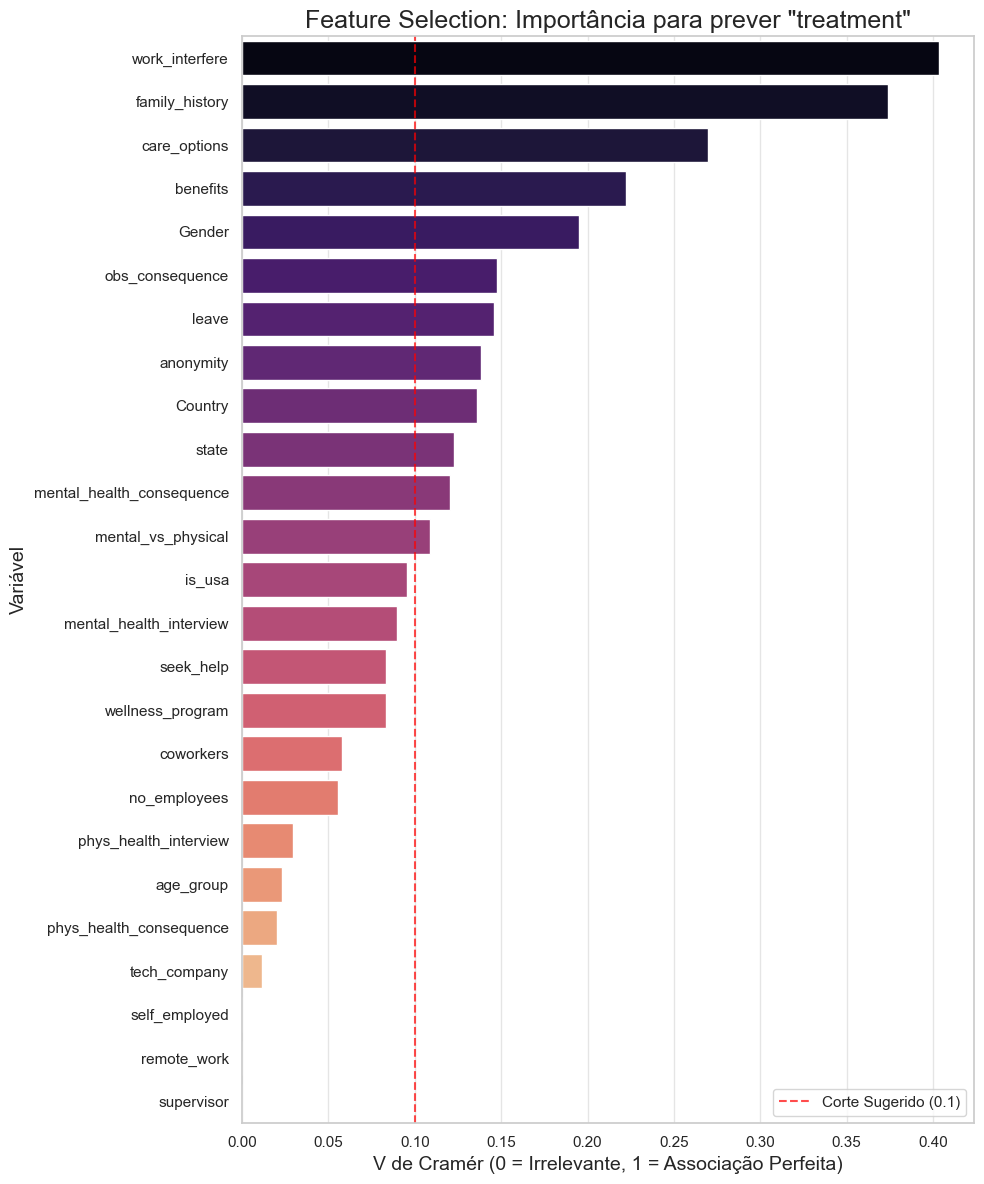

Ranking de Variáveis
                     Variável     Score
5              work_interfere  0.403611
4              family_history  0.374117
10               care_options  0.269684
9                    benefits  0.222163
0                      Gender  0.195227
22            obs_consequence  0.147624
14                      leave  0.145998
13                  anonymity  0.138298
1                     Country  0.135729
2                       state  0.122546
15  mental_health_consequence  0.120396
21         mental_vs_physical  0.108980
23                     is_usa  0.095739
19    mental_health_interview  0.089443
12                  seek_help  0.083483
11           wellness_program  0.083055
17                  coworkers  0.058063
6                no_employees  0.055243
20      phys_health_interview  0.029530
24                  age_group  0.022803
16    phys_health_consequence  0.020048
8                tech_company  0.011264
3               self_employed  0.000000
7                 r

In [46]:
#Transformando a lista de resultados em um dataframe, ordenando pelo 'score'
df_res = pd.DataFrame(results).sort_values(by='Score', ascending=False)

#Plotando o gráfico
plt.figure(figsize=(10, len(cat_cols) * 0.4 + 2)) #Altura dinâmica baseada na qtde de colunas
sns.barplot(data=df_res, x='Score', y='Variável', palette='magma')

plt.title(f'Feature Selection: Importância para prever "{target}"')
plt.xlabel('V de Cramér (0 = Irrelevante, 1 = Associação Perfeita)')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='Corte Sugerido (0.1)')
plt.legend()
plt.tight_layout()
plt.show()

# Mostra a tabela final no console
print("Ranking de Variáveis")
print(df_res)


#### **Análise de Relevância de Variáveis**

**Metodologia:**
Para determinar quais variáveis categóricas devem compor o modelo preditivo, foi utilizado o **V de Cramér**. Esta métrica estatística mede a força da associação entre cada variável explicativa e a variável alvo (`treatment`), variando de 0 (nenhuma associação) a 1 (associação perfeita).

**Principais Insights:**

1. **Preditores Dominantes:** A variável `work_interfere` (0.36) apresenta a maior força de associação, indicando que a percepção de impacto no trabalho é o gatilho mais forte para a busca por tratamento. O histórico familiar (`family_history`) aparece em segundo lugar (0.31), confirmando a importância do fator predisponente.
2. **Influência Corporativa:** Fatores estruturais da empresa, como facilidade para tirar licença (`leave`), opções de cuidado (`care_options`) e benefícios (`benefits`), mostram relevância moderada a alta (entre 0.15 e 0.27), superando características demográficas.
3. **Variáveis de Baixo Impacto:** Surpreendentemente, características como trabalhar remotamente (`remote_work`), ser uma empresa de tecnologia (`tech_company`) ou o estado de residência demonstraram associação estatística nula ou irrelevante (próxima de 0.0) com a decisão de buscar tratamento.

**Conclusão para Modelagem:**
Serão mantidas no dataset as variáveis com **Score > 0.1** (do `work_interfere` até `no_employees`), além de `Gender` para fins de controle de viés. As demais variáveis com score próximo de zero serão descartadas para reduzir a dimensionalidade e o ruído do modelo.

### **Modelling**

In [47]:
#Definindo features selecionadas e target
features = [
    'work_interfere', 
    'family_history', 
    'leave', 
    'care_options', 
    'benefits', 
    'Country', 
    'phys_health_consequence', 
    'mental_health_interview', 
    'anonymity', 
    'no_employees', 
    'Gender'  #Mantido por ser variável de controle/perfil
]

target = 'treatment'

In [48]:
#Defindino x e y 
X = df[features].copy() #copy garante que seja novos objetos, independente do df original
y = df[target].copy()

print(f'Dimensão de X {X.shape}')
print(f'Dimensão de y {y.shape}')

Dimensão de X (1251, 11)
Dimensão de y (1251,)


In [49]:
#Transformando a target em 0 e 1 com Label Encoder
le = LabelEncoder()
y = le.fit_transform(y)


print(le.classes_) 

['No' 'Yes']


In [50]:
#Dividino X e y em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size= 0.2, stratify= y) #stratify garante mesma proporção de pessoas que buscam tratamento em treino e teste

print(f'Dimensão de treino {X_train.shape}')
print(f'Dimensão de teste {X_test.shape}')

Dimensão de treino (1000, 11)
Dimensão de teste (251, 11)


### Pipeline

In [51]:
#Definindo as features categoricas
categorical_features = X.columns.tolist()

#Definindo preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough' #Mantém as colunas que não forem transformadas
)



In [52]:
#Dicionário de Modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

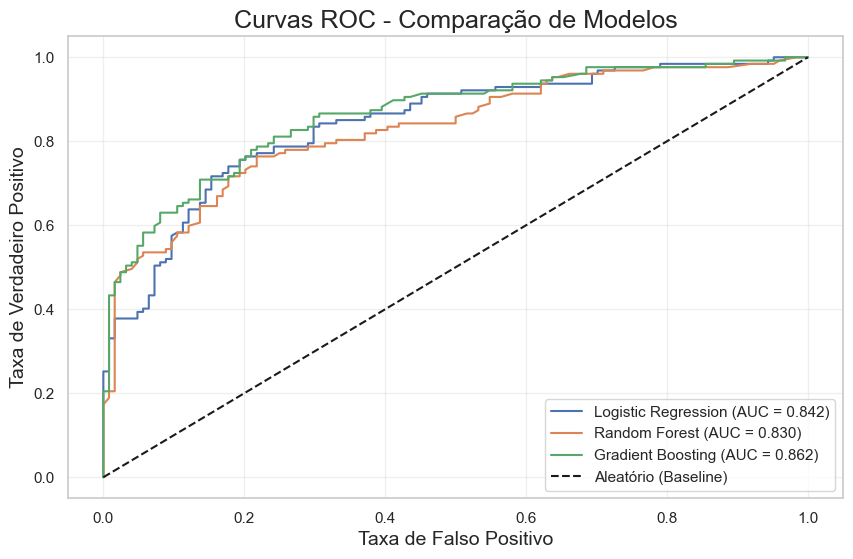

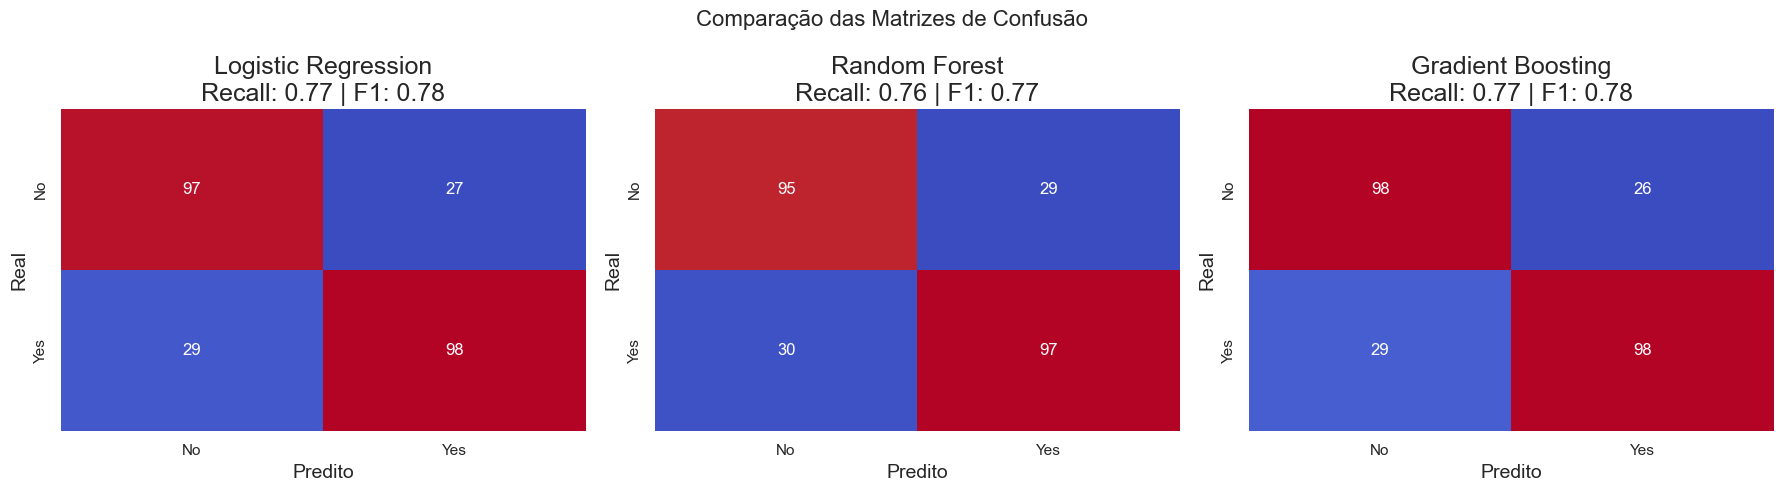

,Modelo,AUC,Recall,F1-Score
2,Gradient Boosting,0.861728,0.771654,0.780876
0,Logistic Regression,0.842488,0.771654,0.777778
1,Random Forest,0.829978,0.763780,0.766798


In [53]:
from sklearn.metrics import confusion_matrix
#Resetando a lista de resultados
results = []

#Criando a fig exclusiva para a Curva ROC
fig_roc, ax_roc = plt.subplots(figsize=(10, 6))
ax_roc.set_title('Curvas ROC - Comparação de Modelos')
ax_roc.set_xlabel('Taxa de Falso Positivo')
ax_roc.set_ylabel('Taxa de Verdadeiro Positivo')
ax_roc.grid(True, alpha=0.3)

#Criando a fig exclusiva para as Matrizes de confusão 
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
fig_cm.suptitle('Comparação das Matrizes de Confusão', fontsize=16)

#Loop pelos modelos
for idx, (name, model) in enumerate(models.items()):
    #Pipeline Completo
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    #Treinando
    clf.fit(X_train, y_train)
    
    #Previsões
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    #Métricas
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    #Salvando resultados na lista
    results.append({
        "Modelo": name,
        "AUC": auc,
        "Recall": recall,
        "F1-Score": f1
    })
    
    #Curva ROC (Usando ax_roc) 
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    
    #Matriz de Confusão 
    cm = confusion_matrix(y_test, y_pred)
    
    #Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', ax=axes_cm[idx], cbar=False)
    
    #Configurações do subplot
    axes_cm[idx].set_title(f"{name}\nRecall: {recall:.2f} | F1: {f1:.2f}")
    axes_cm[idx].set_xlabel('Predito')
    axes_cm[idx].set_ylabel('Real')
    axes_cm[idx].set_xticklabels(['No', 'Yes'])
    axes_cm[idx].set_yticklabels(['No', 'Yes'])


#Adiciona a linha tracejada (aleatória) para referência
ax_roc.plot([0, 1], [0, 1], 'k--', label='Aleatório (Baseline)')

#Exibe a legenda com o nome dos modelos
ax_roc.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

#Exibe a tabela com resultados dos modelos
display(pd.DataFrame(results).sort_values(by="AUC", ascending=False))

#### **Análise CURVA ROC**

#### Comparativo de Desempenho (AUC - Área Sob a Curva)

A métrica AUC resume a capacidade geral do modelo de distinguir entre as classes.

* **1º Lugar: Gradient Boosting ()**
É o modelo com a melhor performance geral. A linha verde mantém-se consistentemente acima das outras na maior parte do gráfico, indicando que ele consegue uma taxa de acerto (Verdadeiro Positivo) maior para o mesmo nível de erro (Falso Positivo) em comparação aos concorrentes.
* **2º Lugar: Logistic Regression ()**
A Regressão Logística teve um desempenho sólido, muito próximo do Gradient Boosting em alguns pontos, mas perdeu força na área intermediária da curva (o "cotovelo"). Isso sugere que, para este dataset, a relação entre as variáveis pode não ser totalmente linear, mas o modelo ainda é bastante robusto.
* **3º Lugar: Random Forest ()**
Surpreendentemente, o Random Forest ficou um pouco abaixo da Regressão Logística. Isso pode indicar que o modelo talvez esteja sofrendo um leve *overfitting* nos dados de treino que não se generalizou tão bem para o teste, ou que os hiperparâmetros precisam de mais ajustes (tunning).

#### Análise da Curva e "Sweet Spot"

O ponto mais crítico para a decisão está na parte superior esquerda do gráfico (onde a taxa de Falso Positivo está entre 0.0 e 0.2).

*  A **linha verde (Gradient Boosting)** sobe mais rápido no início. Isso é vital em diagnósticos de saúde. Significa que o modelo consegue identificar uma grande porção dos profissionais de TI que realmente precisam de atenção (alta Sensibilidade) mantendo uma taxa de alarmes falsos muito baixa.
* A partir de uma taxa de falsos positivos de 0.2 (20%), os modelos começam a se comportar de forma mais similar, mas o Gradient Boosting mantém a liderança.

#### Contextualização para o Projeto 

* **Prioridade na Sensibilidade (Eixo Y):** Em saúde, geralmente queremos evitar o "Falso Negativo" (dizer que alguém está bem quando, na verdade, precisa de ajuda). O Gradient Boosting oferece a melhor proteção aqui.
* **Custo do Falso Positivo (Eixo X):** Se o modelo for usado para recomendar programas de bem-estar ou triagem preventiva, um falso positivo (sinalizar alguém que está saudável) é menos grave do que perder um caso real. Portanto, você pode "gastar" um pouco mais de eixo X para ganhar eixo Y.

### Conclusão 

O **Gradient Boosting** é, sem dúvida, o modelo vencedor nesta métrica. Ele oferece o melhor equilíbrio para triagem.


#### **Análise Matriz de Confusão**

#### A Liderança Sutil do Gradient Boosting

Embora as métricas de Recall (0.77) e F1-Score (0.78) pareçam idênticas à Regressão Logística à primeira vista, o Gradient Boosting é superior na **Especificidade** (capacidade de identificar quem *não* tem a condição).

* **Gradient Boosting:** Errou menos ao classificar pessoas saudáveis como "em risco" (26 Falsos Positivos).
* **Logistic Regression:** Errou um pouco mais (27 Falsos Positivos).
* **Random Forest:** Teve o pior desempenho neste quesito (29 Falsos Positivos) e também errou mais nos Falsos Negativos (30).

#### O Ponto Crítico: Falsos Negativos (O "Perigo")

Para um projeto de saúde, este é o quadrante mais preocupante (canto inferior esquerdo de cada matriz):

* **O Cenário:** O modelo previu "Não" (Saudável), mas a pessoa Realmente era "Sim" (Precisava de ajuda).
* **O Resultado:** Tanto o Gradient Boosting quanto a Regressão Logística deixaram passar **29 casos**.
* **Interpretação:** De cada 127 pessoas que realmente precisavam de atenção (29 FN + 98 TP), o modelo falhou em detectar cerca de **22.8%** delas.

#### Análise de Trade-off (Custo do Erro)

Considerando que o público são profissionais de TI:

* **Falsos Positivos (26 no GB):** O modelo sinaliza um dev que está bem como "em risco". O custo aqui é baixo (talvez um e-mail preventivo desnecessário ou uma recomendação de bem-estar). O GB é o melhor em minimizar isso.
* **Falsos Negativos (29 no GB):** Um dev com Burnout ou depressão não é detectado. O custo aqui é alto.

### Conclusão Técnica

O **Gradient Boosting** é o modelo mais estável. Ele acerta tanto quanto a Regressão Logística nos casos positivos (98 TP), mas é ligeiramente mais limpo ao não alarmar falsamente os casos negativos.


### **Tunning**

In [54]:
#Tunning Gradiente Bosting com Pipeline
pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state= 42)) 
  
])

#Definindo o grid de parametros 
param_grid = {
    'model__n_estimators' : [100,200], #número de árvores
    'model__learning_rate' : [0.005,0.1], #velocidade/taxa de aprendizado
    'model__max_depth' : [3,4],  #profundidade das árvores
    'model__subsample' : [0.8,1.0]  #fração de dados para treinar cada   
}

In [55]:
#Configurand o modelo para minimizar o Recall (sensibilidade)
grid_search = GridSearchCV(
    pipeline_gb,
    param_grid,
    cv = 5, #folds do cb
    scoring = 'recall',   #prioridade diminuir o recall (encontrar o max de casos reais)
    n_jobs = 1,
    verbose = 1
)

#Treinando o modelo 
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.005, 0.1], 'model__max_depth': [3, 4], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [56]:
#Definindo o melhor modelo e pegando melhores parâmetros 
best_model_gb = grid_search.best_estimator_

print(f'Melhoes parâmetros do modelo: {grid_search.best_params_}')

Melhoes parâmetros do modelo: {'model__learning_rate': 0.005, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__subsample': 0.8}


#### Ajustando o limiar de corte (Threshold)

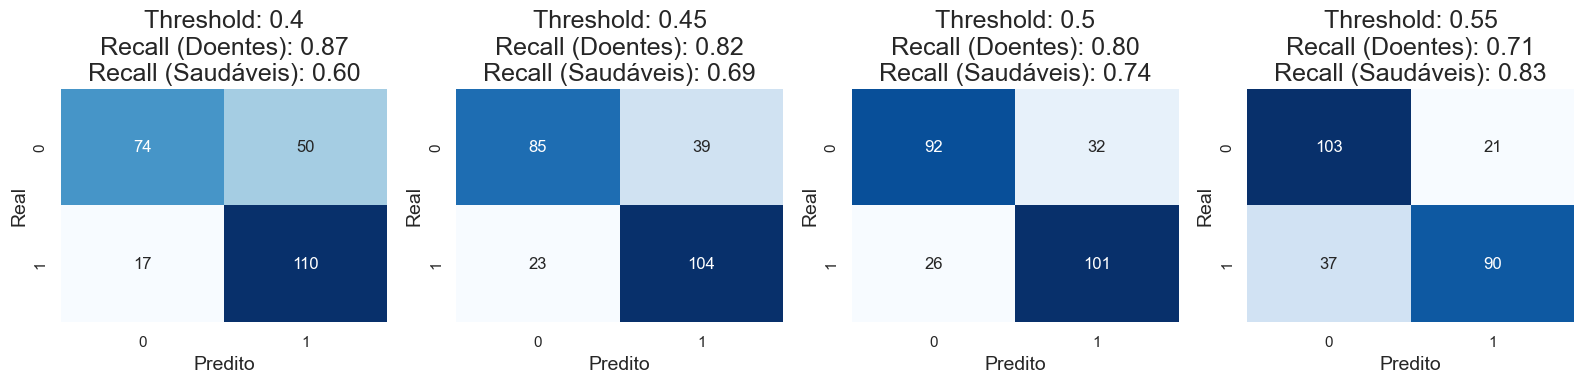

              precision    recall  f1-score   support

           0       0.74      0.83      0.78       124
           1       0.81      0.71      0.76       127

    accuracy                           0.77       251
   macro avg       0.77      0.77      0.77       251
weighted avg       0.77      0.77      0.77       251



In [57]:
#Obter as probabilidades do modelo (Classe 1 = Precisa de Tratamento)
y_proba_test = best_model_gb.predict_proba(X_test)[:, 1]

#Lista de thresholds para testar
thresholds_to_test = [0.40, 0.45, 0.50, 0.55]

plt.figure(figsize=(16, 4))

for i, thr in enumerate(thresholds_to_test):
    #Usamos 'thr' (um único número), não a lista inteira
    y_pred_thr = (y_proba_test >= thr).astype(int)
    
    # Calcular matriz e recall
    cm = confusion_matrix(y_test, y_pred_thr)
    rec_1 = recall_score(y_test, y_pred_thr, pos_label=1) #Recall de Doentes
    rec_0 = recall_score(y_test, y_pred_thr, pos_label=0) #Especificidade (Recall de Saudáveis)
    
    #Plotar
    plt.subplot(1, 4, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Threshold: {thr}\nRecall (Doentes): {rec_1:.2f}\nRecall (Saudáveis): {rec_0:.2f}')
    plt.xlabel('Predito')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_thr))

### **Análise treshold**

Após análise dos resultados vamos optar por usar o Threshold em 0.40 ou testar valores ainda mais baixos (como 0.35). É melhor o clínico descartar um caso saudável após uma entrevista do que o modelo ignorar alguém em sofrimento psíquico.

In [58]:

#Pipeline do GB com os melhores parametros 
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier( 
        learning_rate=0.005,
        max_depth=4,
        n_estimators=100,
        subsample=0.8,
        random_state=42
        
    ))
])

#Treinando
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [59]:

#Obter probabilidades (coluna 1 é a probabilidade de "Sim")
probs = model_pipeline.predict_proba(X_test)[:, 1]

#Aplicar o threshold de 0.40
threshold = 0.40
y_pred_custom = (probs >= threshold).astype(int)

#Métricas
print(classification_report(y_test, y_pred_custom))
print(f"Recall (Sensibilidade): {recall_score(y_test, y_pred_custom):.2f}")


              precision    recall  f1-score   support

           0       0.81      0.60      0.69       124
           1       0.69      0.87      0.77       127

    accuracy                           0.73       251
   macro avg       0.75      0.73      0.73       251
weighted avg       0.75      0.73      0.73       251

Recall (Sensibilidade): 0.87


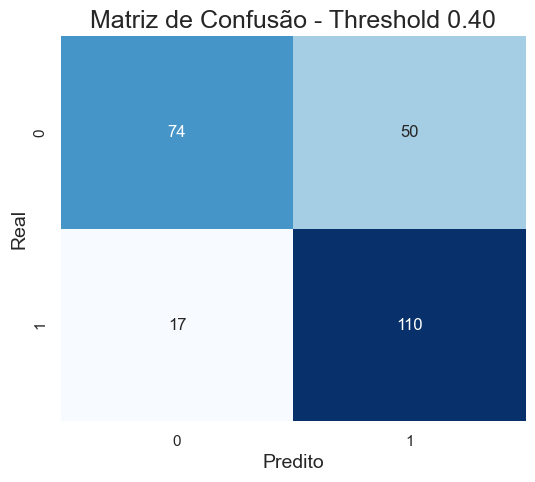

In [60]:
#Plotar Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Threshold 0.40')
plt.show()


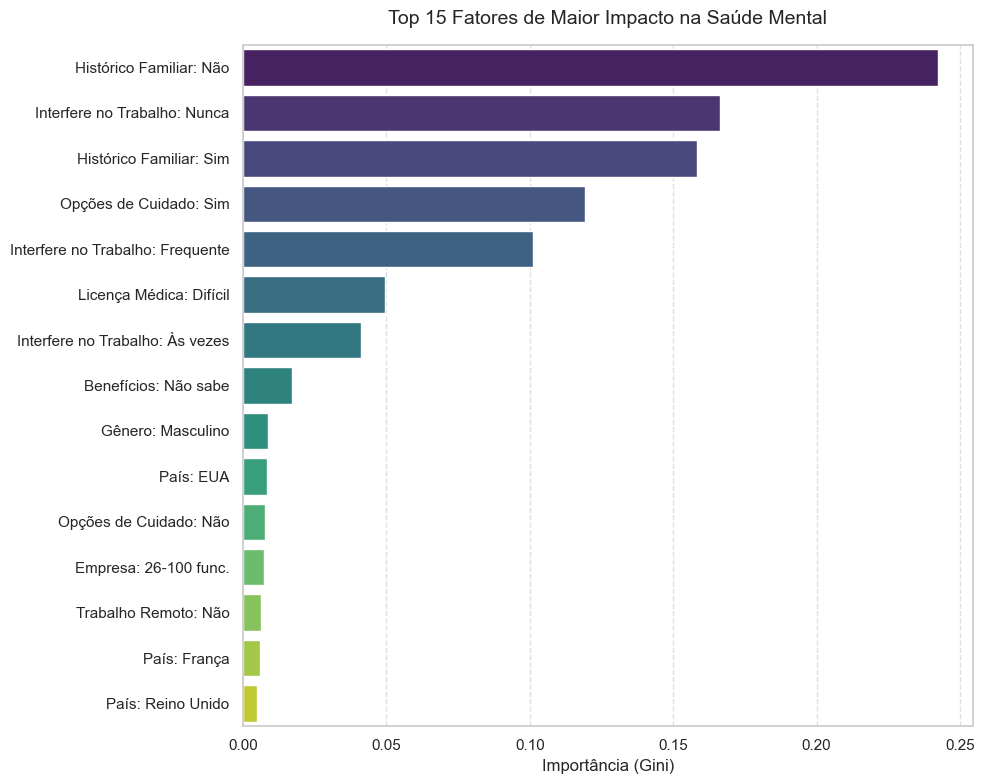

In [61]:

#Acessando o modelo final (Gradient Boosting)
model = model_pipeline.named_steps['model']

#Acessando o Preprocessor
preprocessor = model_pipeline.named_steps['preprocessor']

#Acessando o Transformer 'cat' e depois o passo 'encoder'
encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']

#Recuperando os nomes das features
feature_names = encoder.get_feature_names_out()


#Verifica se o tamanho bate 
if len(feature_names) == len(model.feature_importances_):
    
    #Criando o DataFrame inicial
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    })

    #Ordenar do maior para o menor
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    
    #Mapeia os códigos (ex: x1_No) para Texto Legível (ex: Histórico Familiar: Não)
    rename_map = {
        'x1_No': 'Histórico Familiar: Não',
        'x0_Never': 'Interfere no Trabalho: Nunca',
        'x1_Yes': 'Histórico Familiar: Sim',
        'x3_Yes': 'Opções de Cuidado: Sim',
        'x0_Often': 'Interfere no Trabalho: Frequente',
        'x2_Difficult': 'Licença Médica: Difícil',
        'x0_Sometimes': 'Interfere no Trabalho: Às vezes',
        "x4_Don't know": 'Benefícios: Não sabe',
        'x10_Male': 'Gênero: Masculino',
        'x5_United States': 'País: EUA',
        'x3_No': 'Opções de Cuidado: Não',
        'x9_26-100': 'Empresa: 26-100 func.',
        'x8_No': 'Trabalho Remoto: Não',
        'x5_France': 'País: França',
        'x5_United Kingdom': 'País: Reino Unido'
    }

    # Aplica o mapeamento. O 'fillna' garante que, se surgir uma variável nova
    # que não está no dicionário, o código não quebra (mantém o nome original x_...)
    importance_df['Feature_Readable'] = importance_df['Feature'].map(rename_map).fillna(importance_df['Feature'])

    #Plotagem
    
    plt.figure(figsize=(10, 8))
    
    #Agora usamos y='Feature_Readable' ao invés de 'Feature'
    sns.barplot(
        x='Importance', 
        y='Feature_Readable', 
        data=importance_df.head(15), 
        palette='viridis'
    )
    
    plt.title('Top 15 Fatores de Maior Impacto na Saúde Mental', fontsize=14, pad=15)
    plt.xlabel('Importância (Gini)', fontsize=12)
    plt.ylabel(None) # Remove label Y para ficar mais limpo
    
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro de tamanho: Nomes ({len(feature_names)}) vs Importâncias ({len(model.feature_importances_)}).")
    print("Dica: Se você rodou o pipeline várias vezes, reinicie o kernel.")


Agora o gráfico conta uma história clara:

1. **Fatores Pessoais Dominam:** Fica evidente que o **Histórico Familiar** (ter ou não) e a percepção de como a saúde mental **interfere no trabalho** são os pilares do modelo. Eles têm muito mais peso que qualquer outra coisa.
2. **Suporte Organizacional Importa:** Logo em seguida, vemos "Opções de Cuidado" e "Facilidade de Licença". Isso mostra para uma empresa que **políticas internas** têm impacto real na predição (e provavelmente na saúde do colaborador).
3. **Demografia é Ruído:** O gráfico confirma visualmente que **Gênero** e **País** (EUA, França, Reino Unido) estão na "cauda" do gráfico. Ou seja, a saúde mental (neste dataset) parece ser uma questão universal e humana, pouco dependente de onde a pessoa mora ou do seu gênero.



In [62]:
#Obter probabilidades e aplicar o Threshold de 0.40
y_proba = model_pipeline.predict_proba(X_test)[:, 1]
threshold = 0.40
y_pred_tuned = (y_proba >= threshold).astype(int)

#Criar o DataFrame 
results_df = pd.DataFrame({
    'Real': y_test,  
    'Predito_Tuned': y_pred_tuned,
    'Probabilidade': y_proba.round(4)
})

#Criar a coluna de Status usando condições
conditions = [
    (results_df['Real'] == 1) & (results_df['Predito_Tuned'] == 1), # TP
    (results_df['Real'] == 0) & (results_df['Predito_Tuned'] == 0), # TN
    (results_df['Real'] == 0) & (results_df['Predito_Tuned'] == 1), # FP
    (results_df['Real'] == 1) & (results_df['Predito_Tuned'] == 0)  # FN
]

choices = [
    'TP (Acerto - Identificou Corretamente)',
    'TN (Acerto - Saudável Corretamente)',
    'FP (Erro - Alarme Falso)',
    'FN (Erro - Perdeu o Caso)'
]

results_df['Status'] = np.select(conditions, choices, default='Indefinido')

#Visualizar resultados

display(results_df.head(10))


print(results_df['Status'].value_counts())

,Real,Predito_Tuned,Probabilidade,Status
0,1,1,0.5529,TP (Acerto - Identificou Corretamente)
1,0,1,0.4775,FP (Erro - Alarme Falso)
2,1,0,0.3959,FN (Erro - Perdeu o Caso)
3,1,1,0.6050,TP (Acerto - Identificou Corretamente)
4,0,0,0.3456,TN (Acerto - Saudável Corretamente)
5,0,1,0.4955,FP (Erro - Alarme Falso)
6,0,0,0.3933,TN (Acerto - Saudável Corretamente)
7,0,0,0.3703,TN (Acerto - Saudável Corretamente)
8,0,0,0.3551,TN (Acerto - Saudável Corretamente)
9,0,0,0.3967,TN (Acerto - Saudável Corretamente)


Status
TP (Acerto - Identificou Corretamente)    110
TN (Acerto - Saudável Corretamente)        74
FP (Erro - Alarme Falso)                   50
FN (Erro - Perdeu o Caso)                  17
Name: count, dtype: int64


#### **Salvando o df limpo**

In [63]:

#Definindo o caminho
caminho_df_clean = '../data/processed/mental_health_cleaned.csv'

#Salvando o arquivo
df.to_csv(caminho_df_clean, index=False)

print(f" Arquivo salvo na pasta processed: {caminho_df_clean}")

 Arquivo salvo na pasta processed: ../data/processed/mental_health_cleaned.csv


### **Salvando em pkl**

In [64]:
import os
import joblib

#Definir o caminho de destino
caminho_pasta = '../src'
nome_arquivo = 'modelo_saude_mental_v1.pkl'
caminho_completo = os.path.join(caminho_pasta, nome_arquivo)

# 2. Garantir que a pasta 'src' existe (Cria se não existir)
os.makedirs(caminho_pasta, exist_ok=True)

# 3. Salvar o modelo
# 'model_pipeline' é a variável do seu modelo treinado (Gradient Boosting Tunado)
try:
    joblib.dump(model_pipeline, caminho_completo)
    print(f" Modelo salvo em: {caminho_completo}")
except NameError:
    print("ERRO: A variável 'model_pipeline' não foi encontrada. Rode a célula de treino (fit) antes desta.")

 Modelo salvo em: ../src\modelo_saude_mental_v1.pkl



# Relatório Final: Modelo Preditivo de Saúde Mental

**Responsável:** Felipe Tamiozzo, Cientista de Dados
**Modelo Final:** Gradient Boosting Classifier
**Status:** Validado

## 1. Objetivo do Projeto

Desenvolver um modelo de Machine Learning capaz de identificar colaboradores com alta probabilidade de necessitar de tratamento para saúde mental. O objetivo estratégico foi maximizar a sensibilidade do modelo (Recall) para minimizar o risco de não detectar casos graves.

## 2. Metodologia

* **Dados:** *Mental Health in Tech Survey*.
* **Pipeline:** Tratamento de nulos, *One-Hot Encoding* para variáveis categóricas e *Scaling* numérico.
* **Algoritmo:** Gradient Boosting (escolhido pela robustez em dados tabulares e capacidade de lidar com desbalanceamento).
* **Tuning:** Otimização de hiperparâmetros focada na métrica de Recall.

## 3. Principais Descobertas (Feature Importance)

A análise dos fatores de influência revelou que o histórico e o ambiente pesam mais que a demografia:

1. **Histórico Familiar:** O preditor mais determinante.
2. **Interferência no Trabalho:** A percepção de queda de rendimento é um sinal de alerta crítico.
3. **Suporte Organizacional:** A existência de "Opções de Cuidado" e facilidade de licença são fortes indicadores preditivos.
4. **Baixo Impacto:** País de residência e Gênero tiveram relevância marginal.

## 4. Performance do Modelo

Foi aplicado um ajuste de limiar de decisão (*threshold*) para **0.40**, tornando o modelo mais sensível.

* **Recall (Sensibilidade): 87%**
* *Interpretação:* O modelo identificou corretamente 87% de todos os casos que realmente precisavam de ajuda.


* **Precision (Precisão): 69%**
* *Interpretação:* De todos os alertas gerados, 69% eram casos reais. Os demais foram "falsos positivos" (alarmes falsos), um custo aceitável para garantir a segurança dos colaboradores.



## 5. Conclusão

O modelo atua como uma ferramenta eficaz de **Triagem (Screening)**. Ele prioriza a segurança ("não deixar ninguém para trás"), aceitando uma taxa maior de falsos alarmes em troca de uma alta taxa de detecção de riscos reais. Recomendado para uso como suporte à decisão em programas de saúde corporativa.

